## Скрипт для обработки сырых данных из НКРЯ

загрузим библиотеки

In [1]:
import pandas as pd
from razdel import tokenize
import re
import pymorphy3
import logging


для удобной индексации предложений создадим функцию, которая работает с индексом НКРЯ вида text_id:sentence_id:word_id, преобразовывая его в text_id:sentence_id

In [3]:
def extract_full_sentence_id(example_source):
    """
    Извлекает уникальный идентификатор предложения: text_id:sentence_id
    """
    if pd.isna(example_source):
        return None

    parts = str(example_source).split(':')
    if len(parts) >= 2:
        return f"{parts[0]}:{parts[1]}"  # text_id:sentence_id
    return None

следующая функция нужна для извлечения токена, его начального индекса и конечного

In [4]:
def tokenize_with_offsets(text):
    """
    Возвращает список (token_text, start, end)
    """
    return [(t.text, t.start, t.stop) for t in tokenize(text)]

для проверки принадлежности к одной сущности идущих подряд токенов мы инициализировали проверку падежа. это пригодится, если два токена с тэгом PERS идут подряд, но реферируют к разным сущностям (Катя Машу увидела). работает на основе pymorphy

In [5]:
morph = pymorphy3.MorphAnalyzer()


def get_case(word):
    """
    Определяет падеж слова.
    Возвращает строку с названием падежа или None, если не удалось определить.
    """
    try:
        parsed = morph.parse(word)[0]
        if 'NOUN' in parsed.tag or 'PROPN' in parsed.tag:
            # Извлекаем падеж из тега
            tag = str(parsed.tag)
            # Ищем падеж в теге
            cases = {
                'nomn': 'именительный',
                'gent': 'родительный',
                'datv': 'дательный',
                'accs': 'винительный',
                'ablt': 'творительный',
                'loct': 'предложный',
                'voct': 'звательный'
            }

            for case_code, case_name in cases.items():
                if case_code in tag:
                    return case_name
        return None
    except:
        return None


def are_same_entity(token1, token2):
    """
    Проверяет, могут ли два токена быть частью одной сущности.
    Основано на падеже и других признаках.
    """
    case1 = get_case(token1)
    case2 = get_case(token2)

    # Если оба токена имеют падеж
    if case1 and case2:
        # Если падежи совпадают - скорее всего одна сущность
        if case1 == case2:
            return True
        # Или хотя бы один в именительном (часто имя идет в именительном)
        elif case1 == 'именительный' or case2 == 'именительный':
            return True

    # Если хотя бы у одного не определился падеж, будем считать это одной сущности
    # (лучше объединить, чем разделить)
    if case1 is None or case2 is None:
        return True

    return False


важная ячейка! её необходимо обновлять и затем заново запускать ячейки ниже для каждой новой обработки данных НКРЯ

In [6]:
ENTITY_LABEL = "NORP"    # нужно обновлять (PERS, LOC, NORP)
INPUT_FILE = "NORP2.csv"    # нужно обновлять
OUTPUT_FILE = "NORP_conll2.csv"    # нужно обновлять
OUTPUT_FILE_MAPPING = "NORP_ID_mapping2.csv"   # нужно обновлять

важная функция для обработки предложения. объединяет в себе токенизацию, проставление лейблов

In [7]:
def process_sentence(text, entities_in_sentence):
    """
    Обрабатывает одно предложение со всеми его сущностями
    Возвращает список токенов с правильными метками
    """
    if pd.isna(text) or not entities_in_sentence:
        return []

    tokens = tokenize_with_offsets(text)

    # по умолчанию O
    labels = ['O'] * len(tokens)

    for entity in entities_in_sentence:
        if pd.isna(entity):
            continue

        entity_matches = list(re.finditer(re.escape(entity), text))

        for match in entity_matches:
            entity_start = match.start()
            entity_end = match.end()

            for i, (token, start, end) in enumerate(tokens):
                if not (end <= entity_start or start >= entity_end):
                    # Помечаем пока все как B-, потом исправим)
                    labels[i] = f"B-{ENTITY_LABEL}"

    # Теперь корректируем метки: последовательные B- превращаем в I-
    for i in range(1, len(labels)):
        if labels[i] == f"B-{ENTITY_LABEL}" and labels[i-1] == f"B-{ENTITY_LABEL}":
            curr_token = tokens[i][0]
            prev_token = tokens[i-1][0]

            if tokens[i][1] - tokens[i-1][2] <= 1:  # Разрыв <= 1 символа
                # Проверяем морфологически
                if are_same_entity(prev_token, curr_token):
                    labels[i] = f"I-{ENTITY_LABEL}"

    result = []
    for i, (token, start, end) in enumerate(tokens):
        result.append({
            "Token": token,
            "Label": labels[i],
            "Start": start,
            "End": end
        })

    return result

именно функцию build_conll мы будем применять для сырых данных, она состоит из ранее инициализированных функций. функция save_id_mapping позволит в будущем соотносить новые id предложений (подстроенные под наш датасет) со старыми, которые определены для НКРЯ.

In [8]:
def build_conll(df):
    all_rows = []

    df['text_sentence_id'] = df['Example source'].apply(extract_full_sentence_id)

    new_sentence_counter = 1

    # Словарь для соответствия старых и новых ID
    id_mapping = {}

    # Группируем по уникальному идентификатору предложения (text_id:sentence_id)
    for text_sentence_id, group in df.groupby('text_sentence_id'):
        if text_sentence_id is None:
            continue

        # Присваиваем новое предложение ID
        new_sentence_id = new_sentence_counter
        new_sentence_counter += 1

        # Сохраняем соответствие
        id_mapping[text_sentence_id] = new_sentence_id

        # Берем первый текст из группы (они должны быть одинаковыми)
        text = group.iloc[0]['Full context']

        # Получаем ВСЕ сущности для этого предложения
        entities_in_sentence = group['Center'].dropna().unique().tolist()

        # Обрабатываем предложение со всеми сущностями
        tokens_with_labels = process_sentence(text, entities_in_sentence)

        # Добавляем результат с новой индексацией
        for token_data in tokens_with_labels:
            all_rows.append({
                # Новая сквозная индексация (основная)
                "Sentence_ID": new_sentence_id,

                # Токен и метка
                "Token": token_data["Token"],
                "Label": token_data["Label"],

                # Оригинальный ID (только самый важный)
                "Original_ID": text_sentence_id,

                # Текст предложения (для отладки)
                "Text": text
            })

    return pd.DataFrame(all_rows), id_mapping


def save_id_mapping(mapping, filename="id_mapping.csv"):
    """Сохраняет соответствие старых и новых ID"""
    mapping_df = pd.DataFrame([
        {
            "New_Sentence_ID": new_id,
            "Original_ID": old_id
        }
        for old_id, new_id in mapping.items()
    ])
    mapping_df.to_csv(filename, index=False, encoding="utf-8")

также добавим логирование для отчётности

In [9]:
def setup_logging():
    """Настройка системы логирования"""
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    log_filename = f"ner_processing_{INPUT_FILE}.log"

    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_filename, encoding='utf-8'),
            logging.StreamHandler()  # в консоль вывод
        ]
    )
    return logging.getLogger(__name__)

logger = setup_logging()

def process_dataset():
    """Основная функция обработки датасета"""
    logger.info("Обработка датасета")

    logger.info("1. Загрузка данных...")
    logger.info(f"Попытка загрузить файл: {INPUT_FILE}")
    df = pd.read_csv(INPUT_FILE, sep=';', encoding="utf-8")
    logger.info(f"Данные загружены")

    logger.info("2. Обработка NER...")
    conll_df, id_mapping = build_conll(df)
    logger.info("Обработка NER завершена")

    conll_df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")
    logger.info(f"3. Сохранение основного датасета в {OUTPUT_FILE}")

    save_id_mapping(id_mapping, OUTPUT_FILE_MAPPING)
    logger.info(f"4. Соответствие ID сохранено в {OUTPUT_FILE_MAPPING}")

    # Статистика
    unique_sentences = conll_df['Sentence_ID'].nunique()
    total_tokens = len(conll_df)

    logger.info(f"\n\nОбработано:")
    logger.info(f"Уникальных предложений: {unique_sentences}")
    logger.info(f"Всего токенов: {total_tokens}")


    logger.info(f"\n\nСтатистика разметки:")
    stats = conll_df['Label'].value_counts()
    for label, count in stats.items():
        percentage = count / total_tokens * 100
        logger.info(f"  {label:10} {count:6} ({percentage:5.1f}%)")

    return True

In [10]:
success = process_dataset()

if success:
    logger.info("Скрипт завершил работу успешно")
else:
    logger.error("Скрипт завершил работу с ошибками")

2026-01-29 21:46:57,815 - __main__ - INFO - Обработка датасета
2026-01-29 21:46:57,818 - __main__ - INFO - 1. Загрузка данных...
2026-01-29 21:46:57,819 - __main__ - INFO - Попытка загрузить файл: NORP2.csv
2026-01-29 21:46:57,914 - __main__ - INFO - Данные загружены
2026-01-29 21:46:57,918 - __main__ - INFO - 2. Обработка NER...
2026-01-29 21:47:00,457 - __main__ - INFO - Обработка NER завершена
2026-01-29 21:47:01,411 - __main__ - INFO - 3. Сохранение основного датасета в NORP_conll2.csv
2026-01-29 21:47:01,434 - __main__ - INFO - 4. Соответствие ID сохранено в NORP_ID_mapping2.csv
2026-01-29 21:47:01,441 - __main__ - INFO - 

Обработано:
2026-01-29 21:47:01,442 - __main__ - INFO - Уникальных предложений: 4229
2026-01-29 21:47:01,443 - __main__ - INFO - Всего токенов: 99248
2026-01-29 21:47:01,443 - __main__ - INFO - 

Статистика разметки:
2026-01-29 21:47:01,453 - __main__ - INFO -   O           94240 ( 95.0%)
2026-01-29 21:47:01,455 - __main__ - INFO -   B-NORP       5005 (  5.0%)


## Конкатенация мини-датасетов

In [138]:
INPUT_FILES = [
    "LOC_conll1.csv",
    "LOC_conll2.csv",
    "PERS_conll1.csv",
    "PERS_conll2.csv",
    "NORP_conll1.csv",
    "NORP_conll2.csv"
]

OUTPUT_FILE = "RNC_NER.csv"

In [31]:
def combine_and_reindex(files):
    """
    Объединяет файлы и переиндексирует предложения
    """
    all_dfs = []
    current_max_id = 0

    for i, file in enumerate(files, 1):
        df = pd.read_csv(file, encoding="utf-8")
        df['Sentence_ID'] = df['Sentence_ID'] + current_max_id
        current_max_id = df['Sentence_ID'].max()
        all_dfs.append(df)

    combined_df = pd.concat(all_dfs, ignore_index=True)

    # Перенумеровываем с 1
    unique_ids = combined_df['Sentence_ID'].unique()
    id_mapping = {old: new for new, old in enumerate(sorted(unique_ids), 1)}
    combined_df['Sentence_ID'] = combined_df['Sentence_ID'].map(id_mapping)

    return combined_df

In [ ]:
existing_files = []
for file in INPUT_FILES:
    pd.read_csv(file, encoding="utf-8", nrows=1)
    existing_files.append(file)

result_df = combine_and_reindex(existing_files)
result_df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

In [140]:
print(f"Объединенный файл: {OUTPUT_FILE}")
print(f"Всего токенов: {len(result_df)}")
print(f"Уникальных предложений: {result_df['Sentence_ID'].nunique()}")
print("\nСтатистика меток:")
label_counts = result_df['Label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

Объединенный файл: RNC_NER.csv
Всего токенов: 536544
Уникальных предложений: 23391

Статистика меток:
  O: 506053 (94.3%)
  B-NORP: 10028 (1.9%)
  B-LOC: 9996 (1.9%)
  B-PERS: 9308 (1.7%)
  I-PERS: 1118 (0.2%)
  I-LOC: 33 (0.0%)
  I-NORP: 8 (0.0%)


Сравним с другими датасетами NER

In [78]:
# +-----------------+-------+---------+--------+---------+-----------+
# | Dataset         | Lang  | Sents   | Tokens | Classes | Domain    |
# +-----------------+-------+---------+--------+---------+-----------+
# | CoNLL-2003      | ENG   | 14.000  | 300K   | 4       | News      |
# | OntoNotes 5.0   | ENG   | 75.000  | 1.7M   | 18      | Mixed     |
# | Few-NERD        | ENG   | 188.000 | 4.6M   | 66      | Wiki      |
# | Collection3     | RUS   | 15.000  | 250K   | 3       | News      |
# | NEREL           | RUS   | 56.000  | 500K   | 29      | Wiki/News |
# +-----------------+-------+---------+--------+---------+-----------+
# | RNC-NER         | RUS   | 23.291  | 537K   | 3+      | Misc.     |

## EDA для всего корпуса (PERS + NORP+ LOC)

In [16]:
RNC_NER = pd.read_csv('RNC_NER.csv', sep=';', encoding='cp1251')

In [70]:
RNC_NER[RNC_NER['Sentence_ID']==3011]

,Sentence_ID,Token,Label,Original_ID,Text
70149,3011,Еще,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70150,3011,предстояло,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70151,3011,выполнить,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70152,3011,обещание,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70153,3011,и,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70154,3011,присоединиться,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70155,3011,к,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70156,3011,войне,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70157,3011,против,O,53418:8614,Еще предстояло выполнить обещание и присоедини...
70158,3011,Японии,B-LOC,53418:8614,Еще предстояло выполнить обещание и присоедини...


In [74]:
RNC_NER.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536544 entries, 0 to 536543
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Sentence_ID  536544 non-null  int64 
 1   Token        536544 non-null  object
 2   Label        536544 non-null  object
 3   Original_ID  536544 non-null  object
 4   Text         536544 non-null  object
dtypes: int64(1), object(4)
memory usage: 20.5+ MB


также объединим сеты сырых данных, так как в них хранится важная информация о текстах, полезная для изучения

In [35]:
INPUT_FILES = [
    "LOC1.csv",
    "LOC2.csv",
    "PERS1.csv",
    "PERS2.csv",
    "NORP1.csv",
    "NORP2.csv"
]

OUTPUT_FILE = "RNC_NER_raw.csv"

In [37]:
raw = []
for file in INPUT_FILES:
    df = pd.read_csv(file, sep=';', encoding="utf-8")
    raw.append(df)

RNC_NER_raw = pd.concat(raw, ignore_index=True)
RNC_NER_raw.to_csv(OUTPUT_FILE, index=True, encoding="utf-8")

годы публикаций

In [57]:
RNC_NER_raw['Created_Year'] = pd.to_datetime(
    RNC_NER_raw['Created'],
    dayfirst=True,
    errors='coerce'
)
RNC_NER_raw['Created_Year'] = RNC_NER_raw['Created_Year'].dt.year

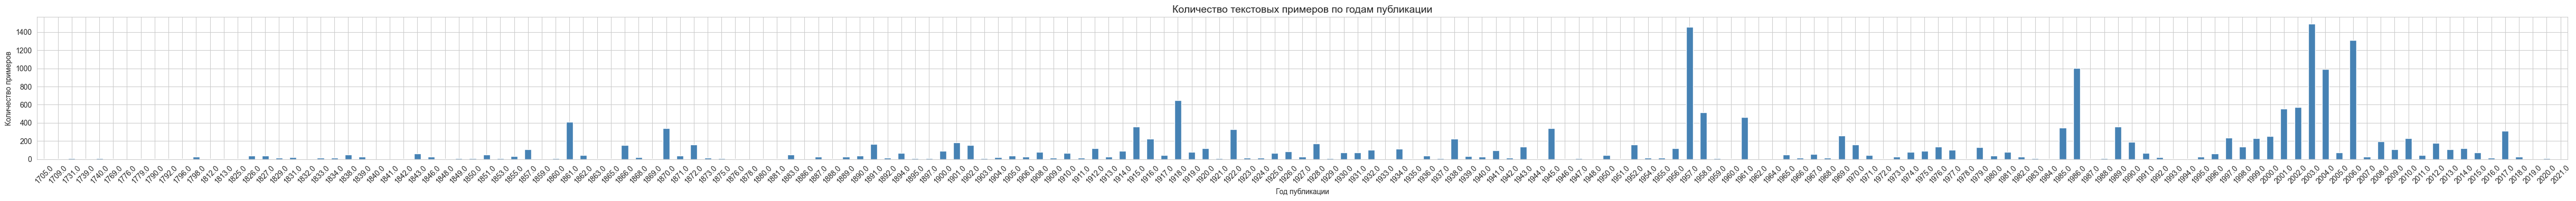

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(50, 5))
RNC_NER_raw['Created_Year'].value_counts().sort_index().plot(kind='bar', color='steelblue', ax=ax)
plt.title('Количество текстовых примеров по годам публикации', fontsize=14)
plt.xlabel('Год публикации')
plt.ylabel('Количество примеров')
plt.xticks(rotation=45)
plt.tight_layout(pad=5.0)  # Добавляем отступы
plt.show()

сфера функционирования на тип текста

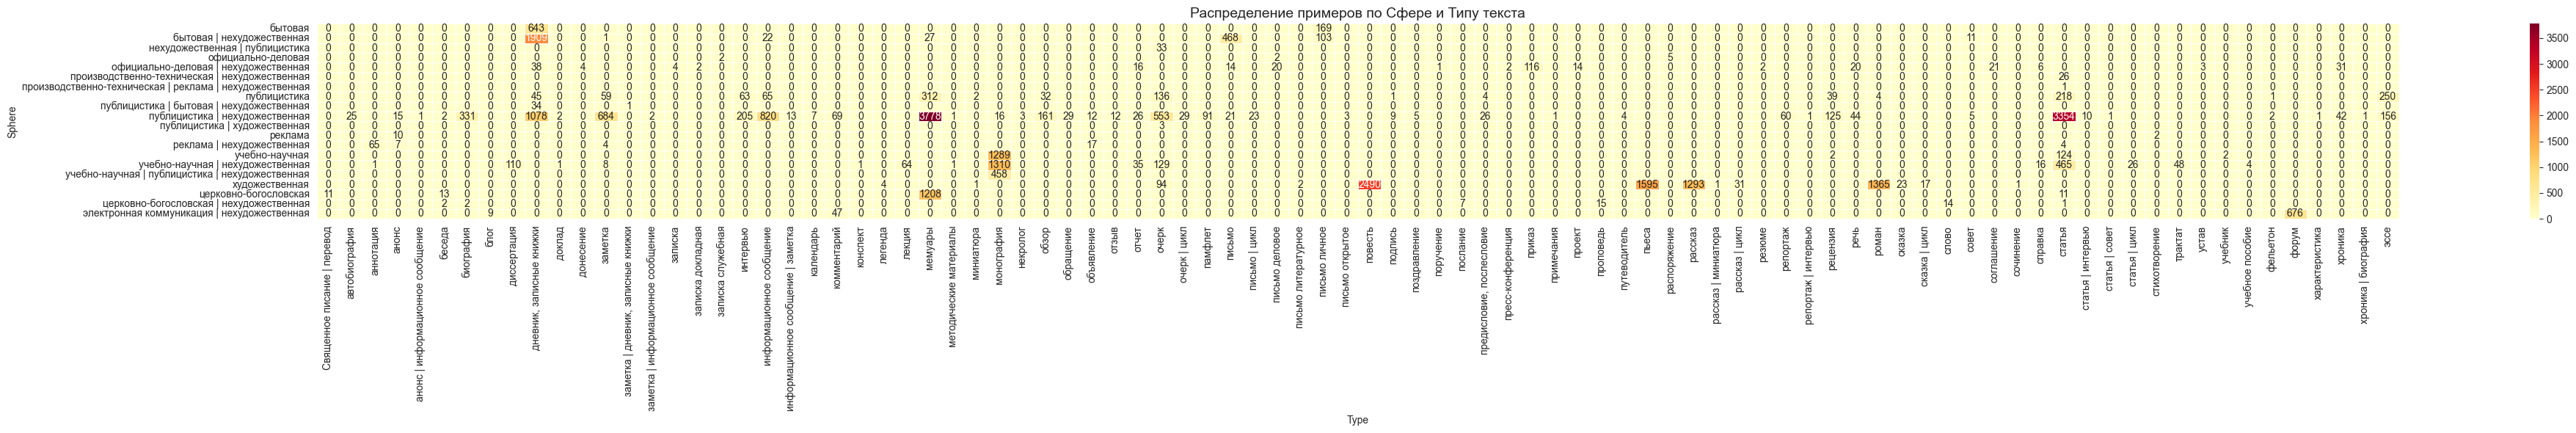

In [49]:
# Crosstab для сферы и типа
sphere_type_ct = pd.crosstab(RNC_NER_raw['Sphere'], RNC_NER_raw['Type'])
plt.figure(figsize=(40, 6))
sns.heatmap(sphere_type_ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=.5)
plt.title('Распределение примеров по Сфере и Типу текста', fontsize=14)
plt.tight_layout()
plt.show()

темы

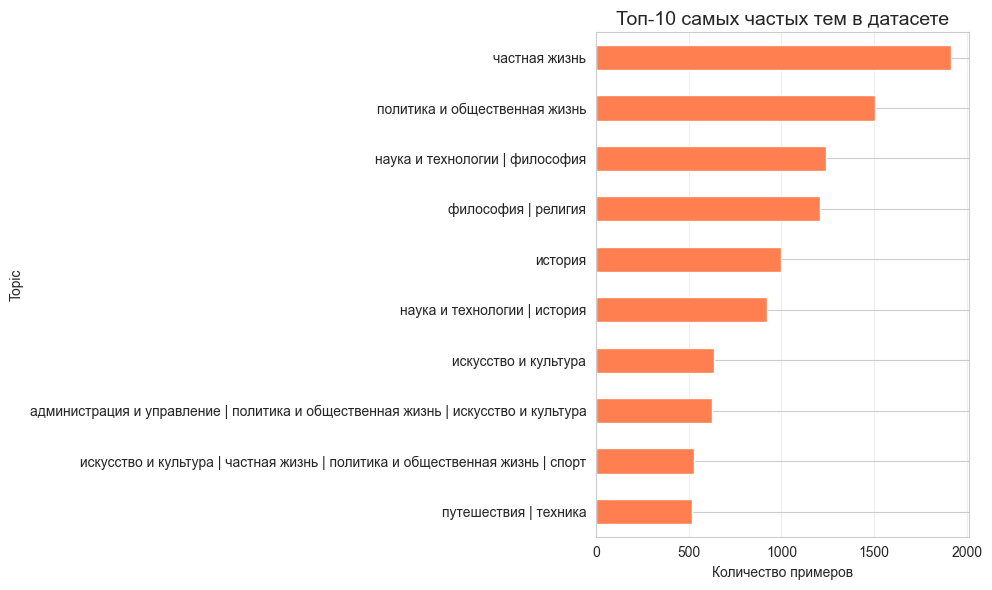

In [40]:
# Топ-10 самых частых тем
top_topics = RNC_NER_raw['Topic'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_topics.sort_values().plot(kind='barh', color='coral')
plt.title('Топ-10 самых частых тем в датасете', fontsize=14)
plt.xlabel('Количество примеров')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

сфера функционирования

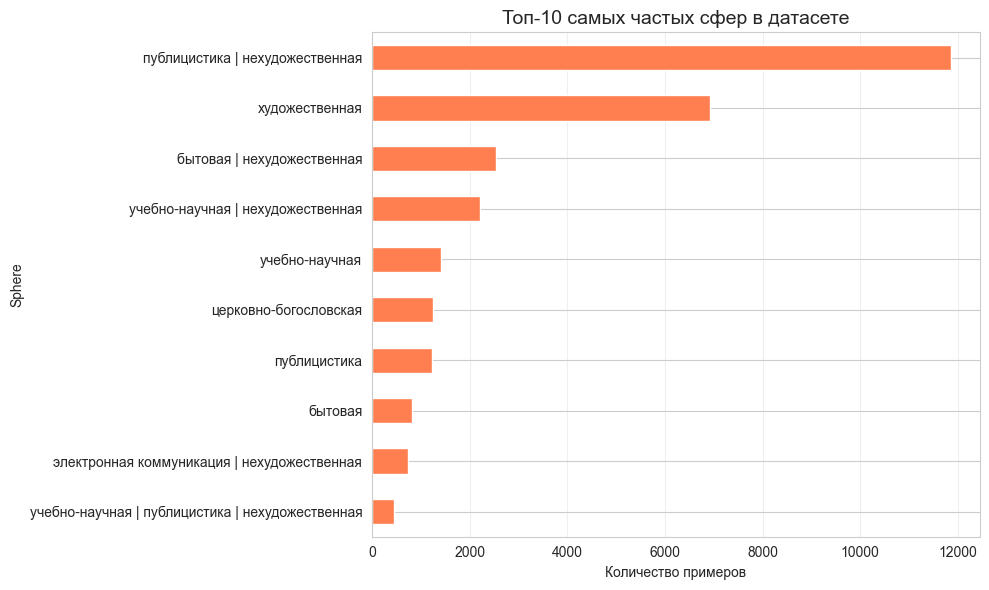

In [72]:
top_sphere = RNC_NER_raw['Sphere'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_sphere.sort_values().plot(kind='barh', color='coral')
plt.title('Топ-10 самых частых сфер в датасете', fontsize=14)
plt.xlabel('Количество примеров')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

тип текста

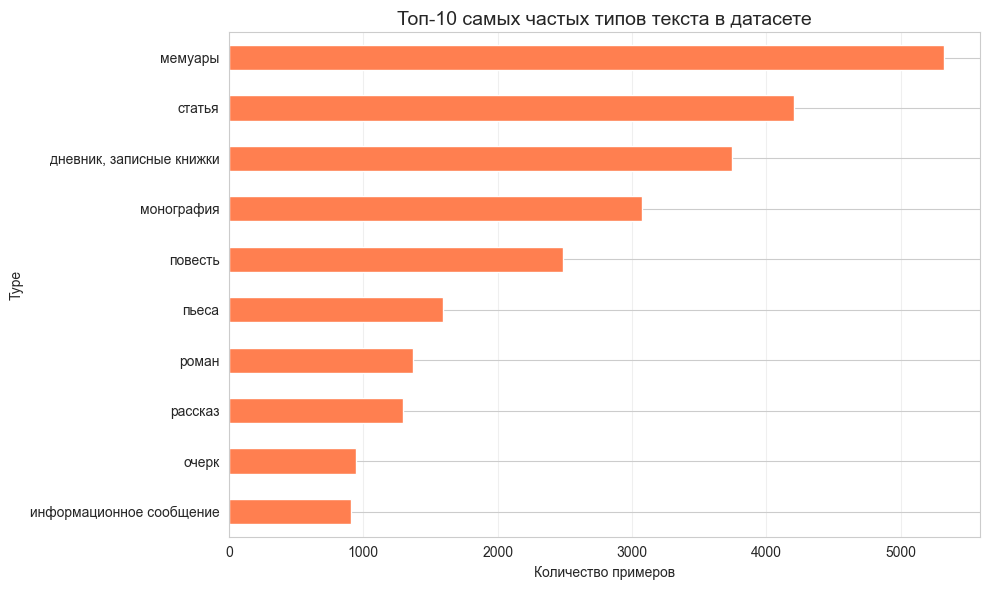

In [73]:
top_type = RNC_NER_raw['Type'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_type.sort_values().plot(kind='barh', color='coral')
plt.title('Топ-10 самых частых типов текста в датасете', fontsize=14)
plt.xlabel('Количество примеров')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

 источники публикаций

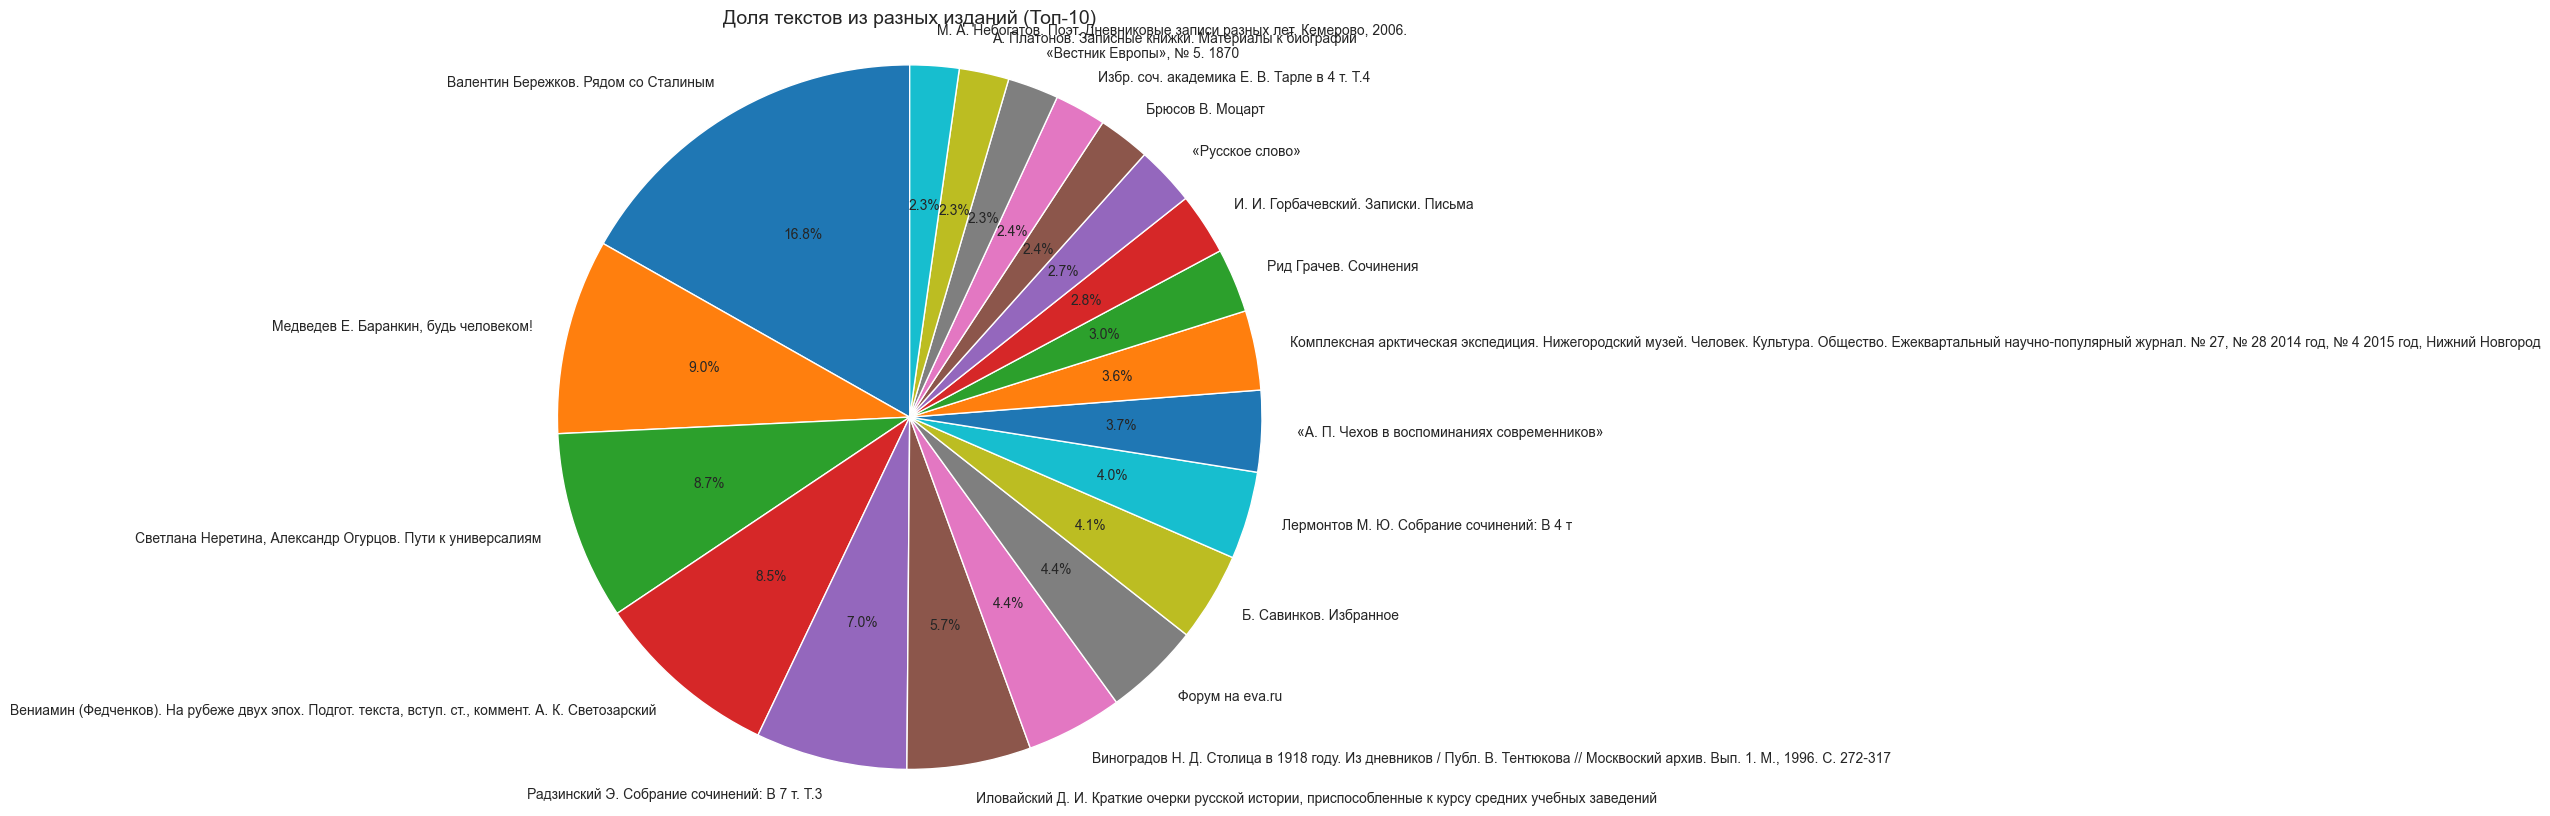

In [59]:
top_pubs = RNC_NER_raw['Publication'].value_counts().head(20)
plt.figure(figsize=(10, 10))
plt.pie(top_pubs.values, labels=top_pubs.index, autopct='%1.1f%%', startangle=90)
plt.title('Доля текстов из разных изданий (Топ-10)', fontsize=14)
plt.axis('equal')
# plt.tight_layout()
plt.show()

длина контекста

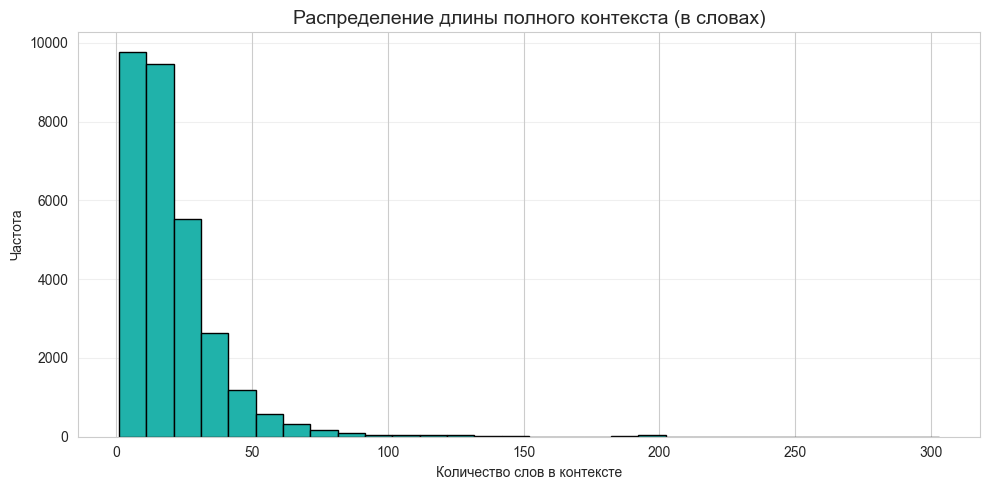

In [42]:
RNC_NER_raw['Full_context_len'] = RNC_NER_raw['Full context'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10,5))
plt.hist(RNC_NER_raw['Full_context_len'], bins=30, color='lightseagreen', edgecolor='black')
plt.title('Распределение длины полного контекста (в словах)', fontsize=14)
plt.xlabel('Количество слов в контексте')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()